### Code funzionante

In [177]:
a = 34340003233212132
b = 2

# 1. LUT a scala 2^128
lut = [(1 << 128) // ((1 << 63) | (i << 56)) for i in range(128)]

# 2. normalizza
s = 64 - b.bit_length()
b_norm = b << s

# 3. stima iniziale
idx = (b_norm >> 56) & 0x7F
x = lut[idx]  # x ≈ 2^128 / b_norm

# 4. Newton-Raphson a scala 2^128
for _ in range(3):
    x = (x * ((2 << 128) - b_norm * x)) >> 128

# x ≈ 2^128 / b_norm = 2^128 / (b * 2^s) = 2^(128-s) / b
# quindi a/b = a * x >> (128 - s)
result = (a * x) >> (128 - s)

print(result)
print(a // b)  # esatto

17170001616606066
17170001616606066


Devono essere 66 polimoni, ad esempio in 0 devo trovare i 66 bit del valore lut[0]. Ogni polinomio interpola su 128 valori

In [178]:
for i in range(128):
    print(lut[i].bit_length())

66
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65
65


### Todo: map the LUT as a polynomial

In [193]:
import numpy as np
import math

def polylut(bit = 0):
    N = 128
    seq = np.array([get_bit(lut[bit], i) for i in range(N)], dtype=float)
    c = np.fft.fft(seq)  

    def f(x):
        s = 0.0
        for k in range(N):
            ang = 2 * math.pi * k * x / N
            s += c[k].real * math.cos(ang) - c[k].imag * math.sin(ang)
        return s / N

    return f

f = polylut(0)

# Verifica sui punti di interpolazione
print("Verifica interpolazione:")
for x in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
    val = f(x)
    expected = polylut(0)(x)
    print(f"  x={x:3d}: f(x)={val:.6f}, f(x)={expected:.6f}, err={abs(val-expected):.2e}")

Verifica interpolazione:
  x=  0: f(x)=-0.000000, f(x)=-0.000000, err=0.00e+00
  x=  1: f(x)=-0.000000, f(x)=-0.000000, err=0.00e+00
  x=  2: f(x)=-0.000000, f(x)=-0.000000, err=0.00e+00
  x=  3: f(x)=0.000000, f(x)=0.000000, err=0.00e+00
  x=  4: f(x)=-0.000000, f(x)=-0.000000, err=0.00e+00
  x=  5: f(x)=-0.000000, f(x)=-0.000000, err=0.00e+00
  x=  6: f(x)=-0.000000, f(x)=-0.000000, err=0.00e+00
  x=  7: f(x)=-0.000000, f(x)=-0.000000, err=0.00e+00
  x=  8: f(x)=0.000000, f(x)=0.000000, err=0.00e+00
  x=  9: f(x)=0.000000, f(x)=0.000000, err=0.00e+00
  x= 10: f(x)=0.000000, f(x)=0.000000, err=0.00e+00


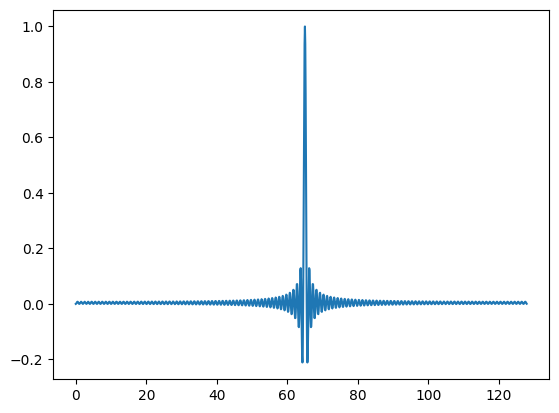

In [198]:
x = np.arange(0, 128, 0.1)

y = np.vectorize(f)(x)

plt.plot(x, y)

In [199]:
import math
import numpy as np
import matplotlib.pyplot as plt
from random import randrange
import random

class Chebyshev:
    """
    Chebyshev(a, b, n, func)
    Given a function func, lower and upper limits of the interval [a,b],
    and maximum degree n, this class computes a Chebyshev approximation
    of the function.
    Method eval(x) yields the approximated function value.
    """
    def __init__(self, a, b, n, func):
        n = n + 1
        self.a = a
        self.b = b
        self.func = func

        bma = 0.5 * (b - a)
        bpa = 0.5 * (b + a)
        f = [func(math.cos(math.pi * (k + 0.5) / n) * bma + bpa) for k in range(n)]
        self.roots = f

        self.x = [math.cos(math.pi * (k + 0.5) / n) * bma + bpa for k in range(n)]

        fac = 2.0 / n
        self.c = [fac * sum([f[k] * math.cos(math.pi * j * (k + 0.5) / n)
                  for k in range(n)]) for j in range(n)]

    def eval(self, x):
        a,b = self.a, self.b
        #assert(a <= x <= b)
        y = (2.0 * x - a - b) * (1.0 / (b - a))
        y2 = 2.0 * y
        (d, dd) = (self.c[-1], 0)             # Special case first step for efficiency
        for cj in self.c[-2:0:-1]:            # Clenshaw's recurrence
            (d, dd) = (y2 * d - dd + cj, d)
        return y * d - dd + 0.5 * self.c[0]   # Last step is different

In [205]:
polyluts = []

for bit in range(66):
    f = polylut(bit)
    
    c = Chebyshev(0, 128, 445, f)
    
    polyluts.append(c)

### Step 1: doing the same as above but with poly

In [234]:
a = 34340003233212132
b = 20

# 1. LUT a scala 2^128
lut = [(1 << 128) // ((1 << 63) | (i << 56)) for i in range(128)]

# 2. normalizza
s = 64 - b.bit_length()
b_norm = b << s

# 3. stima iniziale
idx = (b_norm >> 56) & 0x7F

idx

32

In [235]:
binx = []

for i in range(66):
    if i >= len(polyluts):
        binx.append(0)
    else:
        binx.append(polyluts[i].eval(idx))
    
binx

[-8.786235367735928e-11,
 1.0000000012255712,
 1.2531256587955397e-09,
 1.2111586733531965e-09,
 1.0000000012916685,
 1.1025386714713648e-09,
 1.0000000013312773,
 1.1495437379771545e-09,
 1.0000000012163308,
 1.0000000009940235,
 1.0000000011259833,
 1.0000000010144638,
 1.041416342051349e-09,
 1.2821978478960716e-09,
 9.139700940519191e-10,
 1.0000000010019299,
 1.000000001254526,
 1.153328821335009e-09,
 8.146137375764084e-10,
 1.0000000011121934,
 1.1422664758509171e-09,
 1.0000000013360772,
 1.0910752856752026e-09,
 8.202284407232696e-10,
 1.2420227069043221e-09,
 1.0798140159806735e-09,
 1.245074043865202e-09,
 1.0000000009206658,
 8.174690091511394e-10,
 1.000000001211099,
 1.000000001017309,
 8.954431363061843e-10,
 1.000000001287991,
 1.0979998577020922e-09,
 1.0000000014005304,
 1.000000001195632,
 1.000000001170877,
 1.0000000007780403,
 1.6689686299642403e-09,
 1.2643646130072739e-09,
 8.117907457361184e-10,
 1.0000000016851063,
 1.000000000596878,
 1.2833615281593325e-09,


In [233]:
bits = np.array(binx)[::-1]

# threshold
bits = (bits > 0.5).astype(np.uint8)


n = 0

for i, b in enumerate(bits):
    if b:
        n |= (1 << i)
        
n

21601041014261159143

In [229]:
lut[idx]

29514790517935282585